In [1]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import math
from collections import defaultdict, deque
from ultralytics import YOLO

In [3]:
# ── Added: matplotlib + PIL for live in-notebook charts ──────────────
import matplotlib
matplotlib.use('Agg')          # works inside Jupyter without a display window
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, clear_output

print('Matplotlib imports ready.')


Matplotlib imports ready.


In [4]:
# Load the YOLO model
model = YOLO('yolo11s.pt')

In [5]:
class_list = model.names
class_list

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [6]:
cap = cv2.VideoCapture(r"C:\Users\KIIT\Desktop\TrafficBrain AI\demo_count_vehicles\test_videos\sample_video1.mp4")
print(cap.isOpened())

True


## Speed Zone Configuration
Run **Cell 6** to select your road type and confirm speed limits.
The colour zones (Blue / Green / Yellow / Red) and violation thresholds
are automatically set based on your selection.

In [7]:
# ══════════════════════════════════════════════════════════════════
#  CELL 6 — Road Type Selector + Speed Limits
#  Run this cell, pick your road type, then run the rest as normal.
# ══════════════════════════════════════════════════════════════════

import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Speed limit table (India Motor Vehicles Act + IRC guidelines) ──
ROAD_CONFIGS = {
    "City Road": {
        "car": 50, "motorcycle": 50, "bus": 40, "truck": 40,
        "description": "Urban / city streets"
    },
    "Highway (State)": {
        "car": 100, "motorcycle": 80, "bus": 90, "truck": 80,
        "description": "State highways outside city limits"
    },
    "Highway (National)": {
        "car": 120, "motorcycle": 100, "bus": 100, "truck": 80,
        "description": "4-lane / 6-lane national highways (NH)"
    },
    "Expressway": {
        "car": 120, "motorcycle": 100, "bus": 100, "truck": 80,
        "description": "Access-controlled expressways (e.g. Yamuna, Mumbai-Pune)"
    },
    "School / Hospital Zone": {
        "car": 25, "motorcycle": 25, "bus": 25, "truck": 25,
        "description": "Restricted zones near schools / hospitals"
    },
    "Custom": {
        "car": 50, "motorcycle": 50, "bus": 40, "truck": 40,
        "description": "Set your own limits below"
    },
}

# ── Widgets ────────────────────────────────────────────────────────
road_selector = widgets.Dropdown(
    options=list(ROAD_CONFIGS.keys()),
    value="City Road",
    description="Road Type:",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="340px"),
)

# Custom limit sliders (shown only when "Custom" is selected)
slider_car   = widgets.IntSlider(value=50, min=10, max=160, step=5,
                                  description="Car (km/h):",
                                  style={"description_width": "110px"},
                                  layout=widgets.Layout(width="400px"))
slider_moto  = widgets.IntSlider(value=50, min=10, max=160, step=5,
                                  description="Motorcycle:",
                                  style={"description_width": "110px"},
                                  layout=widgets.Layout(width="400px"))
slider_bus   = widgets.IntSlider(value=40, min=10, max=160, step=5,
                                  description="Bus (km/h):",
                                  style={"description_width": "110px"},
                                  layout=widgets.Layout(width="400px"))
slider_truck = widgets.IntSlider(value=40, min=10, max=160, step=5,
                                  description="Truck (km/h):",
                                  style={"description_width": "110px"},
                                  layout=widgets.Layout(width="400px"))

custom_box = widgets.VBox(
    [slider_car, slider_moto, slider_bus, slider_truck],
    layout=widgets.Layout(display="none", margin="8px 0 0 20px")
)

confirm_btn = widgets.Button(
    description="✅  Confirm Road Type",
    button_style="success",
    layout=widgets.Layout(width="220px", margin="12px 0 0 0"),
)

out = widgets.Output()

# ── Helpers ────────────────────────────────────────────────────────
def show_summary():
    cfg  = ROAD_CONFIGS[road_selector.value]
    lims = {
        "car":        slider_car.value   if road_selector.value == "Custom" else cfg["car"],
        "motorcycle": slider_moto.value  if road_selector.value == "Custom" else cfg["motorcycle"],
        "bus":        slider_bus.value   if road_selector.value == "Custom" else cfg["bus"],
        "truck":      slider_truck.value if road_selector.value == "Custom" else cfg["truck"],
    }
    print(f"  Road Type  : {road_selector.value}")
    print(f"  Description: {cfg['description']}")
    print()
    print("  Speed Limits:")
    for cls, lim in lims.items():
        print(f"    {cls:<12}: {lim} km/h"
              f"   |  Green ≤ {int(lim * 0.75)} km/h"
              f"   |  Yellow {int(lim * 0.75) + 1}–{lim} km/h"
              f"   |  Red > {lim} km/h")

# ── Callbacks ──────────────────────────────────────────────────────
def on_road_change(change):
    custom_box.layout.display = "flex" if change["new"] == "Custom" else "none"
    with out:
        clear_output()

road_selector.observe(on_road_change, names="value")

def on_confirm(b):
    global SPEED_LIMITS, DEFAULT_SPEED_LIMIT, ROAD_TYPE

    cfg = ROAD_CONFIGS[road_selector.value]

    if road_selector.value == "Custom":
        SPEED_LIMITS = {
            "car":        slider_car.value,
            "motorcycle": slider_moto.value,
            "bus":        slider_bus.value,
            "truck":      slider_truck.value,
        }
    else:
        SPEED_LIMITS = {k: v for k, v in cfg.items() if k != "description"}

    DEFAULT_SPEED_LIMIT = SPEED_LIMITS.get("car", 50)
    ROAD_TYPE           = road_selector.value

    with out:
        clear_output()
        print("=" * 56)
        print("  ✅  Speed config confirmed!")
        print("=" * 56)
        show_summary()
        print()
        print("  ▶  You can now run the remaining cells.")

confirm_btn.on_click(on_confirm)

# ── Speed helper functions (same logic, now use dynamic SPEED_LIMITS) ─
def get_speed_color(speed, class_name):
    limit = SPEED_LIMITS.get(class_name, DEFAULT_SPEED_LIMIT)
    if speed <= 10:
        return (255, 100, 0)       # BLUE  — very slow / stopped
    elif speed <= limit * 0.75:
        return (0, 200, 0)         # GREEN — safe
    elif speed <= limit:
        return (0, 220, 255)       # YELLOW — approaching limit
    else:
        return (0, 0, 255)         # RED — violation

def is_violation(speed, class_name):
    return speed > SPEED_LIMITS.get(class_name, DEFAULT_SPEED_LIMIT)

# ── Safe defaults (so cells below don't crash if you skip Confirm) ─
SPEED_LIMITS        = {k: v for k, v in ROAD_CONFIGS["City Road"].items() if k != "description"}
DEFAULT_SPEED_LIMIT = 50
ROAD_TYPE           = "City Road"
PIXELS_PER_METRE    = 8.0   # calibrate for your video

# ── Render UI ──────────────────────────────────────────────────────
display(widgets.VBox([
    widgets.HTML("<b style='font-size:15px'>🛣️  Select Road Type</b>"),
    road_selector,
    custom_box,
    confirm_btn,
    out,
]))


## Challan / Fine System

In [8]:
# ══════════════════════════════════════════════════════════════════
#  CHALLAN / FINE SYSTEM  (integrated from friend's notebook)
#  Fine slabs based on how much OVER the speed limit the vehicle was.
# ══════════════════════════════════════════════════════════════════

# Fine slabs — over_by = actual_speed - class_speed_limit
FINE_SLABS = [
    (1,  15,           500),   # 1–15 km/h over   → ₹500
    (16, 30,          1000),   # 16–30 km/h over  → ₹1,000
    (31, float('inf'),2000),   # 31+ km/h over    → ₹2,000
]

# Heavy vehicles pay 25% extra surcharge
HEAVY_VEHICLE_SURCHARGE = 0.25   # 25%
HEAVY_VEHICLES = {'bus', 'truck'}


def calculate_fine(speed_kmh, class_name, limit_kmh):
    """
    Calculate challan fine in Indian Rupees.
    Returns dict with base_fine, surcharge, total_fine, over_by, slab.
    """
    over_by    = round(speed_kmh - limit_kmh, 1)
    base_fine  = 0
    slab_label = ''

    for low, high, fine in FINE_SLABS:
        if low <= over_by <= high:
            base_fine  = fine
            slab_label = f'{low}–{int(high) if high != float("inf") else "31+"} km/h over'
            break

    surcharge  = int(base_fine * HEAVY_VEHICLE_SURCHARGE) if class_name in HEAVY_VEHICLES else 0
    total_fine = base_fine + surcharge

    return {
        'base_fine':  base_fine,
        'surcharge':  surcharge,
        'total_fine': total_fine,
        'over_by':    over_by,
        'slab':       slab_label,
    }


# ── Print the fine table ─────────────────────────────────────────────
print('CHALLAN / FINE SYSTEM')
print('=' * 52)
print(f'  {"Over limit by":<20} {"Base fine":<14} Notes')
print('-' * 52)
print(f'  {"1–15 km/h":<20} {"Rs. 500":<14} All vehicles')
print(f'  {"16–30 km/h":<20} {"Rs. 1000":<14} All vehicles')
print(f'  {"31+ km/h":<20} {"Rs. 2000":<14} All vehicles')
print()
print(f'  Heavy vehicle surcharge: +{int(HEAVY_VEHICLE_SURCHARGE*100)}%  (bus, truck)')
print(f'  e.g. truck at 31+ over limit → Rs. 2000 + Rs. 500 = Rs. 2500')


CHALLAN / FINE SYSTEM
  Over limit by        Base fine      Notes
----------------------------------------------------
  1–15 km/h            Rs. 500        All vehicles
  16–30 km/h           Rs. 1000       All vehicles
  31+ km/h             Rs. 2000       All vehicles

  Heavy vehicle surcharge: +25%  (bus, truck)
  e.g. truck at 31+ over limit → Rs. 2000 + Rs. 500 = Rs. 2500


## Live Matplotlib Chart System

In [9]:
# ══════════════════════════════════════════════════════════════════
#  LIVE MATPLOTLIB CHART SYSTEM  (integrated from friend's notebook)
#  Renders a live bar + line chart inside the notebook every N frames.
# ══════════════════════════════════════════════════════════════════

# ── Chart data stores ─────────────────────────────────────────────────
chart_frame_times  = []                   # frame numbers for x-axis
chart_avg_speeds   = []                   # overall avg speed per snapshot
chart_class_speeds = defaultdict(list)    # per-class avg speed history

CHART_UPDATE_EVERY = 10                   # redraw chart every N frames
CHART_CLASS_COLORS = {
    'car':        '#3498db',
    'motorcycle': '#e67e22',
    'bus':        '#2ecc71',
    'truck':      '#e74c3c',
}


def draw_live_chart(frame_idx, track_speeds, track_classes):
    """
    Renders a matplotlib figure inside the Jupyter notebook cell.
    Shows:
      Left  — Bar chart of current avg speed per vehicle class
      Right — Line chart of overall avg speed over time
    Called every CHART_UPDATE_EVERY frames from the main loop.
    """
    # collect current smooth speeds per class
    class_current_speeds = defaultdict(list)
    for tid, spds in track_speeds.items():
        if spds:
            cname = track_classes.get(tid, 'unknown')
            class_current_speeds[cname].append(float(np.median(list(spds))))

    if not class_current_speeds:
        return

    classes    = list(class_current_speeds.keys())
    avg_spds   = [np.mean(class_current_speeds[c]) for c in classes]
    bar_colors = [CHART_CLASS_COLORS.get(c, '#95a5a6') for c in classes]

    # append to timeline
    overall_avg = np.mean([s for spds in class_current_speeds.values() for s in spds])
    chart_frame_times.append(frame_idx)
    chart_avg_speeds.append(round(overall_avg, 1))

    # draw figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    fig.patch.set_facecolor('#1a1a2e')
    for ax in (ax1, ax2):
        ax.set_facecolor('#16213e')
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.title.set_color('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

    # left: bar chart per class
    bars = ax1.bar(classes, avg_spds, color=bar_colors, width=0.5)
    ax1.set_title('Avg speed by class  (frame ' + str(frame_idx) + ')')
    ax1.set_ylabel('km/h')
    ax1.set_ylim(0, max(max(SPEED_LIMITS.values()) * 1.4, 20))
    # draw speed limit line per class
    for i, cls in enumerate(classes):
        lim = SPEED_LIMITS.get(cls, DEFAULT_SPEED_LIMIT)
        ax1.hlines(lim, i - 0.3, i + 0.3, colors='red', linewidths=1.5, linestyles='--')
    # add value labels on bars
    for bar, val in zip(bars, avg_spds):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}', ha='center', va='bottom', color='white', fontsize=9)

    # right: speed timeline line
    ax2.plot(chart_frame_times, chart_avg_speeds, color='#00d4ff', linewidth=1.5)
    ax2.fill_between(chart_frame_times, chart_avg_speeds, alpha=0.2, color='#00d4ff')
    ax2.set_title('Overall avg speed over time')
    ax2.set_xlabel('Frame')
    ax2.set_ylabel('km/h')
    ax2.set_ylim(0, max(max(SPEED_LIMITS.values()) * 1.4, 20))
    ax2.axhline(DEFAULT_SPEED_LIMIT, color='red', linestyle='--',
                linewidth=1, label='default limit')

    plt.tight_layout()

    # convert figure to PIL image and display in notebook
    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    buf = buf[:, :, :3]   # drop alpha channel
    plt.close(fig)
    clear_output(wait=True)
    display(Image.fromarray(buf))


print('Live chart system ready!')
print(f'  Chart updates every {CHART_UPDATE_EVERY} frames')


Live chart system ready!
  Chart updates every 10 frames


## Speed Helper Function

In [10]:
def estimate_speed(positions, fps):
    """
    Calculate speed in km/h from last 2 tracked positions.
    positions: deque of (cx, cy, frame_idx) tuples
    """
    if len(positions) < 2:
        return 0.0
    (x1, y1, f1), (x2, y2, f2) = positions[-2], positions[-1]
    if f2 == f1:
        return 0.0
    pixel_distance = math.hypot(x2 - x1, y2 - y1)
    metres         = pixel_distance / PIXELS_PER_METRE
    seconds        = (f2 - f1) / fps
    return (metres / seconds) * 3.6   # m/s → km/h

print("estimate_speed() ready.")

estimate_speed() ready.


## Main Tracking Loop


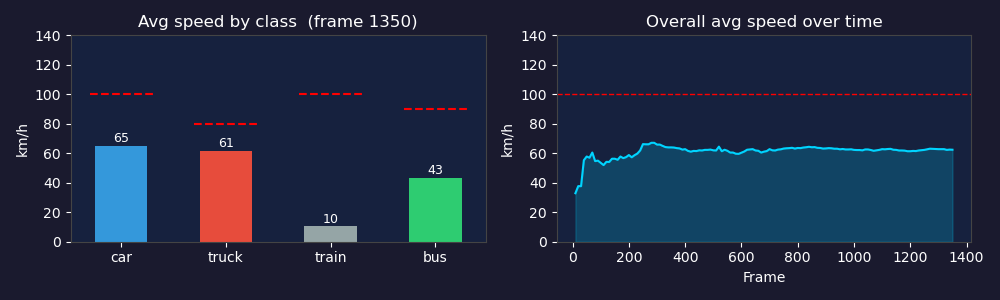


0: 320x576 12 cars, 131.2ms
Speed: 4.0ms preprocess, 131.2ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 576)

0: 320x576 11 cars, 103.5ms
Speed: 2.2ms preprocess, 103.5ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 576)

0: 320x576 10 cars, 111.7ms
Speed: 3.7ms preprocess, 111.7ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 576)

0: 320x576 10 cars, 104.8ms
Speed: 3.7ms preprocess, 104.8ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 576)

0: 320x576 10 cars, 106.7ms
Speed: 3.1ms preprocess, 106.7ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 576)

0: 320x576 11 cars, 106.4ms
Speed: 4.4ms preprocess, 106.4ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 576)

0: 320x576 11 cars, 102.4ms
Speed: 3.2ms preprocess, 102.4ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 576)


In [11]:
line_y_red = 430  # Red line position  ← your original, unchanged

# ── Your original counters ───────────────────────────────────────────
class_counts = defaultdict(int)
crossed_ids  = set()

# ── Added: speed tracking state ──────────────────────────────────────
track_positions = defaultdict(lambda: deque(maxlen=30))
track_speeds    = defaultdict(lambda: deque(maxlen=30))
track_classes   = {}          # remember each track's class name
violations      = []

# ── Reset chart state ────────────────────────────────────────────────
chart_frame_times = []
chart_avg_speeds  = []

fps       = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO tracking  ← YOUR LINE, unchanged
    results = model.track(frame, persist=True, classes=[1, 2, 3, 5, 6, 7], conf=0.25, imgsz=576)

    if results[0].boxes.data is not None:
        boxes         = results[0].boxes.xyxy.cpu()
        track_ids     = results[0].boxes.id.int().cpu().tolist()
        class_indices = results[0].boxes.cls.int().cpu().tolist()
        confidences   = results[0].boxes.conf.cpu()

        # Draw the red counting line  ← YOUR LINE, unchanged
        # Right lane (original)
        cv2.line(frame, (690, line_y_red), (1130, line_y_red), (0, 0, 255), 3)
        # Left lane (added)
        cv2.line(frame, (150, line_y_red), (520, line_y_red), (0, 0, 255), 3)

        for box, track_id, class_idx, conf in zip(boxes, track_ids, class_indices, confidences):
            x1, y1, x2, y2 = map(int, box)
            cx = (x1 + x2) // 2   # ← your centre point
            cy = (y1 + y2) // 2

            class_name = class_list[class_idx]   # ← your class lookup
            track_classes[track_id] = class_name

            # ── Added: speed estimation ───────────────────────────────
            track_positions[track_id].append((cx, cy, frame_idx))

            raw_speed = estimate_speed(track_positions[track_id], fps)
            if raw_speed > 0:
                track_speeds[track_id].append(raw_speed)

            smooth_speed = (
                float(np.median(list(track_speeds[track_id])))
                if track_speeds[track_id] else 0.0
            )

            # ── Added: colour from speed zone rules ───────────────────
            box_color = get_speed_color(smooth_speed, class_name)

            # Your original centre dot  ← unchanged
            cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

            # Your original label — extended with speed
            label = f"ID: {track_id} {class_name}  {smooth_speed:.0f} km/h"
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

            # Your original rectangle — colour now reflects speed zone
            cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 2)

            # ── Added: red circle + SPEEDING tag for violations ───────
            if is_violation(smooth_speed, class_name):
                cv2.circle(frame, (cx, cy), 35, (0, 0, 255), 2)
                cv2.putText(frame, "SPEEDING", (x1, y2 + 18),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2)

            # Your original crossing logic  ← unchanged
            if cy > line_y_red and track_id not in crossed_ids:
                crossed_ids.add(track_id)
                class_counts[class_name] += 1

                # ── Added: log violation at crossing moment ────────────
                if is_violation(smooth_speed, class_name):
                    limit = SPEED_LIMITS.get(class_name, DEFAULT_SPEED_LIMIT)

                    # ── Added: calculate challan fine ─────────────────
                    challan = calculate_fine(smooth_speed, class_name, limit)

                    violations.append({
                        "frame":      frame_idx,
                        "track_id":   track_id,
                        "class":      class_name,
                        "speed_kmh":  round(smooth_speed, 1),
                        "limit_kmh":  limit,
                        "over_by":    challan['over_by'],
                        "fine":       challan['total_fine'],
                        "base_fine":  challan['base_fine'],
                        "surcharge":  challan['surcharge'],
                        "slab":       challan['slab'],
                    })
                    print(f"  VIOLATION! #{track_id} {class_name} "
                          f"{smooth_speed:.1f} km/h  (limit {limit} km/h)  "
                          f"FINE: Rs.{challan['total_fine']:,}")

        y_offset = 30
        for class_name, count in class_counts.items():
            cv2.putText(frame, f"{class_name}: {count}", (50, y_offset),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            y_offset += 30

        # TOTAL count below per-class counts
        total_vehicles = sum(class_counts.values())
        cv2.putText(frame, f"TOTAL: {total_vehicles}", (50, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        # violation count overlay (top-right)
        viol_text = f"Violations: {len(violations)}"
        cv2.putText(frame, viol_text, (frame.shape[1] - 230, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        # speed zone colour legend (bottom-left, top-down)
        legend = [
            ((255, 100, 0), " BLUE   0-10 km/h        Slow/Stopped"),
            ((0, 200, 0),   " GREEN  11-75% of limit  Safe"),
            ((0, 220, 255), " YELLOW 75%-class limit  Caution"),
            ((0, 0, 255),   " RED    >class limit     Violation"),
        ]
        legend_start_y = frame.shape[0] - 10 - len(legend) * 22
        for i, (col, txt) in enumerate(legend):
            ly = legend_start_y + i * 22
            cv2.rectangle(frame, (8, ly - 14), (18, ly), col, -1)
            cv2.putText(frame, txt, (22, ly - 2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (220, 220, 220), 1)

    cv2.imshow("YOLO Object Tracking & Counting", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    # ── Added: update live matplotlib chart every N frames ────────────
    if frame_idx % CHART_UPDATE_EVERY == 0 and frame_idx > 0:
        draw_live_chart(frame_idx, track_speeds, track_classes)

    frame_idx += 1

cap.release()
cv2.destroyAllWindows()


## Results Summary
Reflects the road type and speed limits you selected in Cell 6.

In [12]:
print("=" * 58)
print(f"  SMART TRAFFIC ANALYSIS - {ROAD_TYPE.upper()} RESULTS")
print("=" * 58)
print()
print("VEHICLE COUNTS  (crossed red line)")
for vtype, count in class_counts.items():
    lim = SPEED_LIMITS.get(vtype, DEFAULT_SPEED_LIMIT)
    print(f"  {vtype:<14}: {count}  (speed limit {lim} km/h)")
print(f"  {'TOTAL':<14}: {sum(class_counts.values())}")
print()
print("SPEED STATISTICS")
all_speeds = [s for spds in track_speeds.values() for s in spds]
if all_speeds:
    print(f"  Mean speed   : {np.mean(all_speeds):.1f} km/h")
    print(f"  Median speed : {np.median(all_speeds):.1f} km/h")
    print(f"  Max speed    : {np.max(all_speeds):.1f} km/h")
else:
    print("  No speed data collected.")
print()
print("SPEED VIOLATIONS")
print(f"  Total : {len(violations)}")
for v in violations:
    print(f"    Frame {v['frame']:>5}  #{v['track_id']:<4}  "
          f"{v['class']:<12}  {v['speed_kmh']} km/h  "
          f"(limit {v['limit_kmh']} km/h)")
print()

# ── Added: Challan / Fine Report ──────────────────────────────────────
print("=" * 70)
print("  CHALLAN / FINE REPORT")
print("=" * 70)

if not violations:
    print("  No violations recorded.")
else:
    total_revenue    = 0
    revenue_by_class = defaultdict(int)
    count_by_slab    = defaultdict(int)

    print()
    print(f"  {'#':<4} {'Frame':<7} {'ID':<6} {'Class':<12} "
          f"{'Speed':<10} {'Over by':<10} {'Base':<10} {'Surcharge':<12} {'FINE':<10} Slab")
    print("-" * 100)

    for i, v in enumerate(violations, 1):
        total_revenue           += v['fine']
        revenue_by_class[v['class']] += v['fine']
        count_by_slab[v['slab']]     += 1

        surcharge_str = f"Rs.{v['surcharge']:,}" if v['surcharge'] > 0 else '—'
        print(f"  {i:<4} {v['frame']:<7} #{v['track_id']:<5} {v['class']:<12} "
              f"{v['speed_kmh']:<6} km/h  "
              f"+{v['over_by']:<7}   "
              f"Rs.{v['base_fine']:<7,} "
              f"{surcharge_str:<12} "
              f"Rs.{v['fine']:<8,} "
              f"{v['slab']}")

    print("-" * 100)
    print()
    print(f"  TOTAL FINES COLLECTED : Rs. {total_revenue:,}")
    print()
    print("  Revenue by vehicle class:")
    for cls, amt in sorted(revenue_by_class.items(), key=lambda x: -x[1]):
        print(f"    {cls:<14}: Rs. {amt:,}")
    print()
    print("  Violations by slab:")
    for slab, cnt in sorted(count_by_slab.items()):
        print(f"    {slab:<25}: {cnt} vehicle(s)")

print()
print("COLOUR KEY  (Speed Zone Rules)")
print("  BLUE   box :  0-10 km/h          Very slow / stopped")
print("  GREEN  box :  11 - 75% of limit  Safe speed")
for cls, lim in SPEED_LIMITS.items():
    print(f"               {cls:<12}: up to {int(lim * 0.75)} km/h")
print("  YELLOW box :  75% - class limit  Approaching limit, caution")
for cls, lim in SPEED_LIMITS.items():
    print(f"               {cls:<12}: {int(lim * 0.75)+1}-{lim} km/h")
print("  RED    box :  above class limit  Violation + SPEEDING tag + red circle")
for cls, lim in SPEED_LIMITS.items():
    print(f"               {cls:<12}: > {lim} km/h")


  SMART TRAFFIC ANALYSIS - HIGHWAY (STATE) RESULTS

VEHICLE COUNTS  (crossed red line)
  car           : 135  (speed limit 100 km/h)
  truck         : 11  (speed limit 80 km/h)
  bus           : 3  (speed limit 90 km/h)
  TOTAL         : 149

SPEED STATISTICS
  Mean speed   : 82.1 km/h
  Median speed : 38.2 km/h
  Max speed    : 648.3 km/h

SPEED VIOLATIONS
  Total : 2
    Frame   531  #351   car           108.8 km/h  (limit 100 km/h)
    Frame   539  #353   car           120.3 km/h  (limit 100 km/h)

  CHALLAN / FINE REPORT

  #    Frame   ID     Class        Speed      Over by    Base       Surcharge    FINE       Slab
----------------------------------------------------------------------------------------------------
  1    531     #351   car          108.8  km/h  +8.8       Rs.500     —            Rs.500      1–15 km/h over
  2    539     #353   car          120.3  km/h  +20.3      Rs.1,000   —            Rs.1,000    16–30 km/h over
-------------------------------------------------

In [13]:
import json as _json
import re as _re

# ── Export results directly into dashboard_combined.html ─────────────
all_speeds = [s for spds in track_speeds.values() for s in spds]

total_fines = sum(v['fine'] for v in violations)

_results = {
    "road_type": ROAD_TYPE,
    "speed_limits": SPEED_LIMITS,
    "vehicle_counts": dict(class_counts),
    "total_vehicles": sum(class_counts.values()),
    "violations": violations,          # now includes fine/slab/over_by fields
    "total_fines_inr": total_fines,    # ← added for challan page
    "speed_stats": {
        "mean":   round(float(__import__('numpy').mean(all_speeds)), 1) if all_speeds else 0,
        "median": round(float(__import__('numpy').median(all_speeds)), 1) if all_speeds else 0,
        "max":    round(float(__import__('numpy').max(all_speeds)), 1) if all_speeds else 0,
    }
}

_json_str = _json.dumps(_results, indent=2)

# Read dashboard_combined.html and inject the data directly into it
with open("dashboard_combined.html", "r", encoding="utf-8") as _f:
    _html = _f.read()

# Replace the data placeholder between the injection markers
_html = _re.sub(
    r'// %%DATA_START%%.*?// %%DATA_END%%',
    lambda _: f'// %%DATA_START%%\nconst INJECTED_DATA = {_json_str};\n// %%DATA_END%%',
    _html, flags=_re.DOTALL
)

with open("dashboard_combined.html", "w", encoding="utf-8") as _f:
    _f.write(_html)

print("✅ dashboard_combined.html updated with your results!")
print(f"   Total vehicles : {_results['total_vehicles']}")
print(f"   Violations     : {len(_results['violations'])}")
print(f"   Avg speed      : {_results['speed_stats']['mean']} km/h")
print(f"   Total fines    : Rs. {total_fines:,}")
print()
print("▶  Open dashboard_combined.html from Windows Explorer.")


✅ dashboard_combined.html updated with your results!
   Total vehicles : 149
   Violations     : 2
   Avg speed      : 82.1 km/h
   Total fines    : Rs. 1,500

▶  Open dashboard_combined.html from Windows Explorer.
